In [1]:
import math
import os
import scipy
from scipy.optimize import lsq_linear
import numpy as np
from scipy.linalg import toeplitz
import matplotlib.pyplot as plt
from scipy.stats import multivariate_normal, halfnorm
import random
from scipy.io import loadmat
import random
import pickle
import sys
from sklearn.linear_model import RidgeCV
sys.path.append(r"c:\Users\katie\OneDrive\Documents\GitHub\trial")
import PCA_Regress as pcar
from brokenaxes import brokenaxes
from matplotlib.gridspec import GridSpec

In [2]:
base_path =r"c:\Users\katie\OneDrive\Desktop\Thesis"
with open(base_path+'\J_neu.pkl', "rb") as input_file:
    J_pickle = pickle.load(input_file)
del input_file

file_path = os.path.join(base_path, 'N_neu.pkl')
with open(file_path, "rb") as input_file:
    N_pickle = pickle.load(input_file)
del input_file

base_path =r"c:\Users\katie\OneDrive\Desktop\Thesis"
with open(base_path+'\J_mus.pkl', "rb") as input_file:
    J_pickle_m = pickle.load(input_file)
del input_file

ile_path = os.path.join(base_path, 'N_mus.pkl')
with open(ile_path, "rb") as input_file:
    N_pickle_m = pickle.load(input_file)
del input_file

# base_path = "/Users/kb6113/Desktop/Thesis"
# with open(base_path+'/J_neu.pkl', "rb") as input_file:
#     J_pickle = pickle.load(input_file)
# del input_file

# with open(base_path+'/J_mus.pkl', "rb") as input_file:
#     J_pickle_m = pickle.load(input_file)
# del input_file

J_all_tensor = J_pickle['J_all']['interpPSTH']
J_M1_tensor = J_pickle['J_M1']['interpPSTH']
J_PMd_tensor = J_pickle['J_PMd']['interpPSTH']
J_idx = np.r_[0:18, 36:45]
J_ntm_tensor = J_all_tensor[J_idx, :, :]
J_mus_tensor = J_pickle_m['interpPSTH']


N_all_tensor = N_pickle['N_all']['interpPSTH']
N_M1_tensor = N_pickle['N_M1']['interpPSTH']
N_PMd_tensor = N_pickle['N_PMd']['interpPSTH']
N_mus_tensor = N_pickle_m['interpPSTH']

<>:2: SyntaxWarning: invalid escape sequence '\J'
<>:12: SyntaxWarning: invalid escape sequence '\J'
<>:2: SyntaxWarning: invalid escape sequence '\J'
<>:12: SyntaxWarning: invalid escape sequence '\J'
C:\Users\katie\AppData\Local\Temp\ipykernel_48316\3800015342.py:2: SyntaxWarning: invalid escape sequence '\J'
  with open(base_path+'\J_neu.pkl', "rb") as input_file:
C:\Users\katie\AppData\Local\Temp\ipykernel_48316\3800015342.py:12: SyntaxWarning: invalid escape sequence '\J'
  with open(base_path+'\J_mus.pkl', "rb") as input_file:


[ 4 25 23 22 11 18  3 13 24  1 19 26  0  2  9 20 15  5 14 12 17  6]
>>> best_lam returning: 11.937766417144381


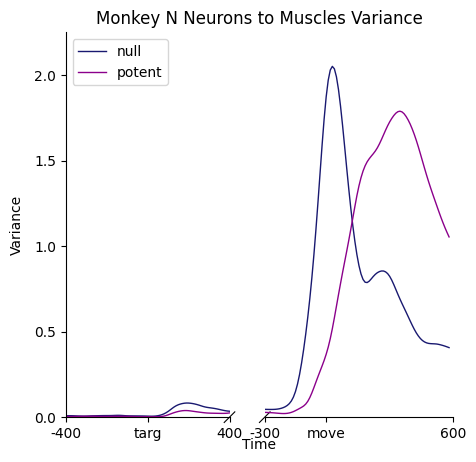

In [3]:
pcar.sup_tuning(N_all_tensor, N_mus_tensor)

[25 26 18  8 17  4 10 16 11 20  5 19 14 15  7  3 13 21  6 22  9  2]
>>> best_lam returning: 100.0


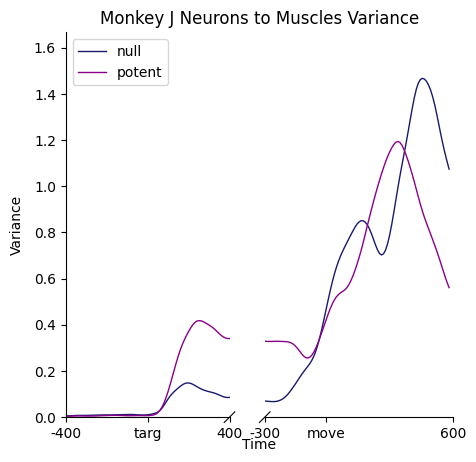

In [4]:
pcar.sup_tuning(J_ntm_tensor, J_mus_tensor)

# best lam = 100

[26 15 22 23  9  6 25 12 17  3 24 14 16 21 11  2 13  4 19  8  5 18]
>>> best_lam returning: 11.937766417144381


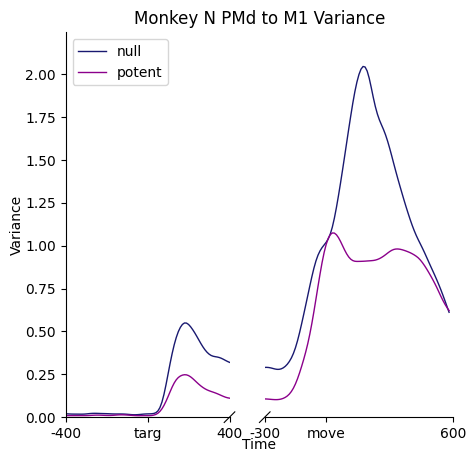

In [5]:
pcar.sup_tuning(N_PMd_tensor, N_M1_tensor, dims = 14) 

# best lam = 58.780160722749116

[ 27  61  56  80  24  87  45 100  73  91  97  60 104  70   1 102  15  10
  28   5  36  49  99 106  63  82 107  11  89  55  77  67  98  42  17  69
   8  93  90  43  76  18  75  33 105  92  46  26  51  59 103  68  78  50
   9  34  22   7  79  31  14  86  19 101  83  23  40   3  52  53  96  25
  84  12  57  66  37  38  48  35  62   2  72  44   4  88  64]
>>> best_lam returning: 11.937766417144381


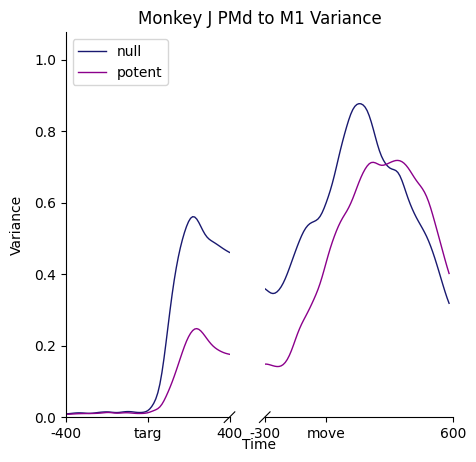

In [6]:
pcar.sup_tuning(J_PMd_tensor, J_M1_tensor, dims = 14)

[  7  72  19  28  98  43  41  90 100  48  22  21   6  29  63  69   1  57
 105  81   8  71  83  39  87  76 103  30  82  31  65  15   3  42  11  49
  14  20  67  17  78  99  70  35  25  79  51  18  61  74  13  32  36  94
  24  80  97  10  91  96  56  54  46  88  62   5  47  52  58  95 107  40
  89  26  37  59  55  12 104  34  84  86   9  16  45  64   4]
>>> best_lam returning: 11.937766417144381


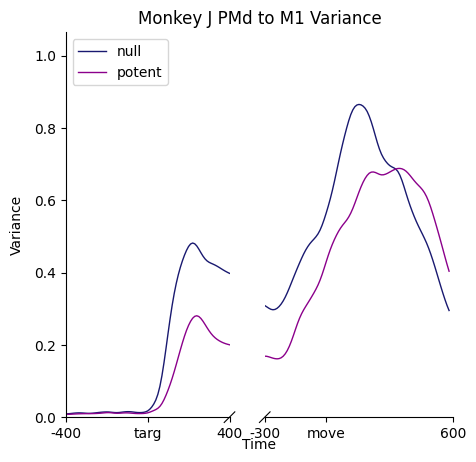

In [7]:
pcar.sup_tuning(J_PMd_tensor, J_M1_tensor, dims = 14)

[19 25 11 17  3 15 21 20  5  1  6 13  0  4 22 24 14 16  7 12  9  8]
>>> best_lam returning: 11.937766417144381


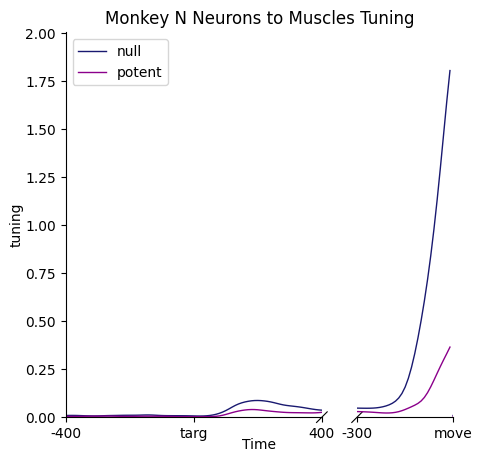

In [8]:
pcar.sup_tuning(N_all_tensor, N_mus_tensor, fig_4D = True)

In [9]:
def fig4_d (tensor_N, tensor_M, dims):

    
    # retrieving dataset specifications 
    J, PMd = pcar.ident(tensor_N)

    # getting weights matrix for potent and null space 
    cond, _, fin_time = tensor_N.shape
    regress_N, _, _ = pcar.time_shift(tensor_N, tensor_M, fig4 = True)
    N_tilde, _, _ = pcar.run_PCA(regress_N, dims)
    W_potent, W_null = pcar.tuning_setup(tensor_N, tensor_M, dims, time = True)
    
    # projecting the neural activity of 400ms before and after target and 300ms before and 800ms after move starts onto the potent and null space of the weights matrix
    N_potent = N_tilde @ W_potent
    N_null = N_tilde @ W_null

    # reshaping into a tensor 
    pot_tensor = pcar.shape_tensor(N_potent, cond)
    null_tensor = pcar.shape_tensor(N_null, cond)
    _, _, time = pot_tensor.shape

    # initializing array for holding the variance 
    V_pot = np.zeros(time)
    V_null = np.zeros(time)
    _, _, time = null_tensor.shape

    ratio = np.zeros(time)

    for t in range(time):

        Xn = null_tensor[:,:,t]
        Xp = pot_tensor[:,:,t]

        # subtract condition mean
        Xn -= Xn.mean(axis=0, keepdims=True)
        Xp -= Xp.mean(axis=0, keepdims=True)

        V_null = np.sum(Xn**2)
        V_pot  = np.sum(Xp**2)

        ratio[t] = (1/gamma) * (V_null / V_pot)